In [1]:
from pathlib import Path

print("Current directory:", Path.cwd())

Current directory: /Users/Sincl/hackmit/hackMIT/notebooks


### Importing Data

In [3]:
DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "training"
TEST_DIR = DATA_DIR / "testing"

In [4]:
print(TRAIN_DIR.resolve())
print(TRAIN_DIR.exists())

/Users/Sincl/hackmit/hackMIT/data/training
True


In [5]:
patients = sorted(TRAIN_DIR.glob("patient*"))

print("Number of training patients:", len(patients))
print(patients[:5])

Number of training patients: 100
[PosixPath('../data/training/patient001'), PosixPath('../data/training/patient002'), PosixPath('../data/training/patient003'), PosixPath('../data/training/patient004'), PosixPath('../data/training/patient005')]


In [8]:
patients = sorted(TRAIN_DIR.glob("patient*"))

print("Number of training patients:", len(patients))
print(patients[:5])

Number of training patients: 100
[PosixPath('../data/training/patient001'), PosixPath('../data/training/patient002'), PosixPath('../data/training/patient003'), PosixPath('../data/training/patient004'), PosixPath('../data/training/patient005')]


### Looking at one patient

In [9]:
# Inspecting one patient

patient_dir = TRAIN_DIR / "patient001"

for file in sorted(patient_dir.iterdir()):
    print(file.name)

Info.cfg
MANDATORY_CITATION.md
patient001_4d.nii.gz
patient001_frame01.nii.gz
patient001_frame01_gt.nii.gz
patient001_frame12.nii.gz
patient001_frame12_gt.nii.gz


In [10]:
info_path = patient_dir / "Info.cfg"

with open(info_path, "r") as f:
    print(f.read())

ED: 1
ES: 12
Group: DCM
Height: 184.0
NbFrame: 30
Weight: 95.0



In [ ]:
# Parses the file so we can have it in a dict, later on this will 
# be useful when looking at many patients
def read_patient_info(patient_dir):
    info = {}

    with open(patient_dir / "Info.cfg", "r") as f:
        for line in f:
            if ":" in line:
                key, value = line.strip().split(":", 1)
                info[key.strip()] = value.strip()

    return info


info = read_patient_info(patient_dir)
info

{'ED': '1',
 'ES': '12',
 'Group': 'DCM',
 'Height': '184.0',
 'NbFrame': '30',
 'Weight': '95.0'}

In [12]:
print("Group:", info.get("Group"))
print("ED frame:", info.get("ED"))
print("ES frame:", info.get("ES"))

Group: DCM
ED frame: 1
ES frame: 12


## Loading one MRI

In [21]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [22]:
patient_name = patient_dir.name

ed_frame = int(info["ED"])

ed_path = patient_dir / f"{patient_name}_frame{ed_frame:02d}.nii.gz"

print(ed_path)

../data/training/patient001/patient001_frame01.nii.gz


In [23]:
ed_img = nib.load(ed_path)
ed = ed_img.get_fdata()

print("Shape:", ed.shape)
print("Voxel spacing:", ed_img.header.get_zooms())
print("Min:", ed.min())
print("Max:", ed.max())

Shape: (216, 256, 10)
Voxel spacing: (np.float32(1.5625), np.float32(1.5625), np.float32(10.0))
Min: 0.0
Max: 658.0


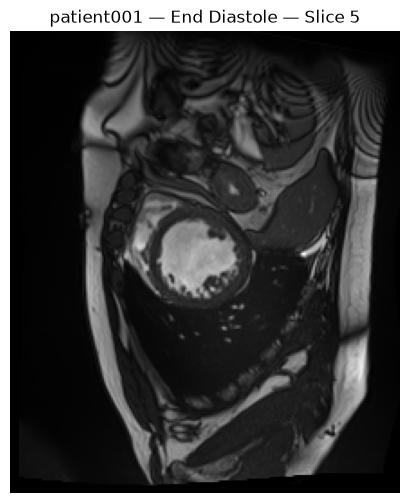

In [24]:
z = ed.shape[2] // 2

plt.figure(figsize=(6, 6))

plt.imshow(
    ed[:, :, z].T,
    cmap="gray",
    origin="lower"
)

plt.title(
    f"{patient_name} — End Diastole — Slice {z}"
)

plt.axis("off")
plt.show()

In [25]:
gt_path = patient_dir / f"{patient_name}_frame{ed_frame:02d}_gt.nii.gz"

gt_img = nib.load(gt_path)
gt = gt_img.get_fdata()

print("GT shape:", gt.shape)
print("Labels:", np.unique(gt))

GT shape: (216, 256, 10)
Labels: [0. 1. 2. 3.]


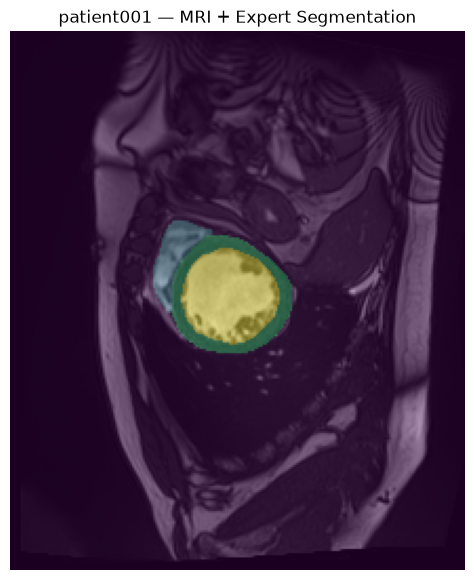

In [26]:
plt.figure(figsize=(7, 7))

plt.imshow(
    ed[:, :, z].T,
    cmap="gray",
    origin="lower"
)

plt.imshow(
    gt[:, :, z].T,
    cmap="viridis",
    origin="lower",
    alpha=0.4
)

plt.title(
    f"{patient_name} — MRI + Expert Segmentation"
)

plt.axis("off")
plt.show()

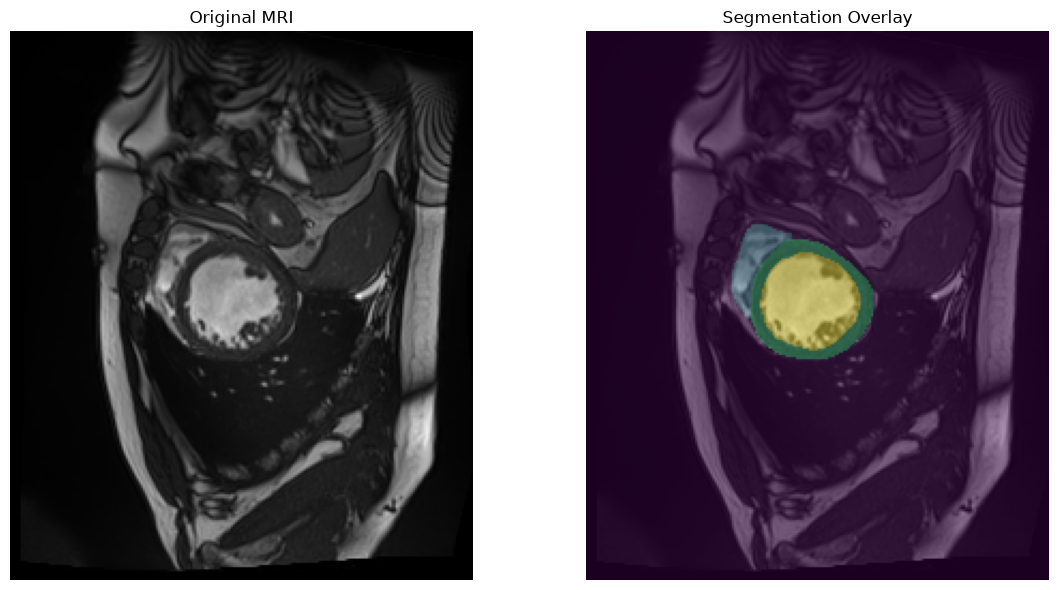

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(
    ed[:, :, z].T,
    cmap="gray",
    origin="lower"
)

axes[0].set_title("Original MRI")
axes[0].axis("off")


axes[1].imshow(
    ed[:, :, z].T,
    cmap="gray",
    origin="lower"
)

axes[1].imshow(
    gt[:, :, z].T,
    cmap="viridis",
    origin="lower",
    alpha=0.4
)

axes[1].set_title("Segmentation Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()

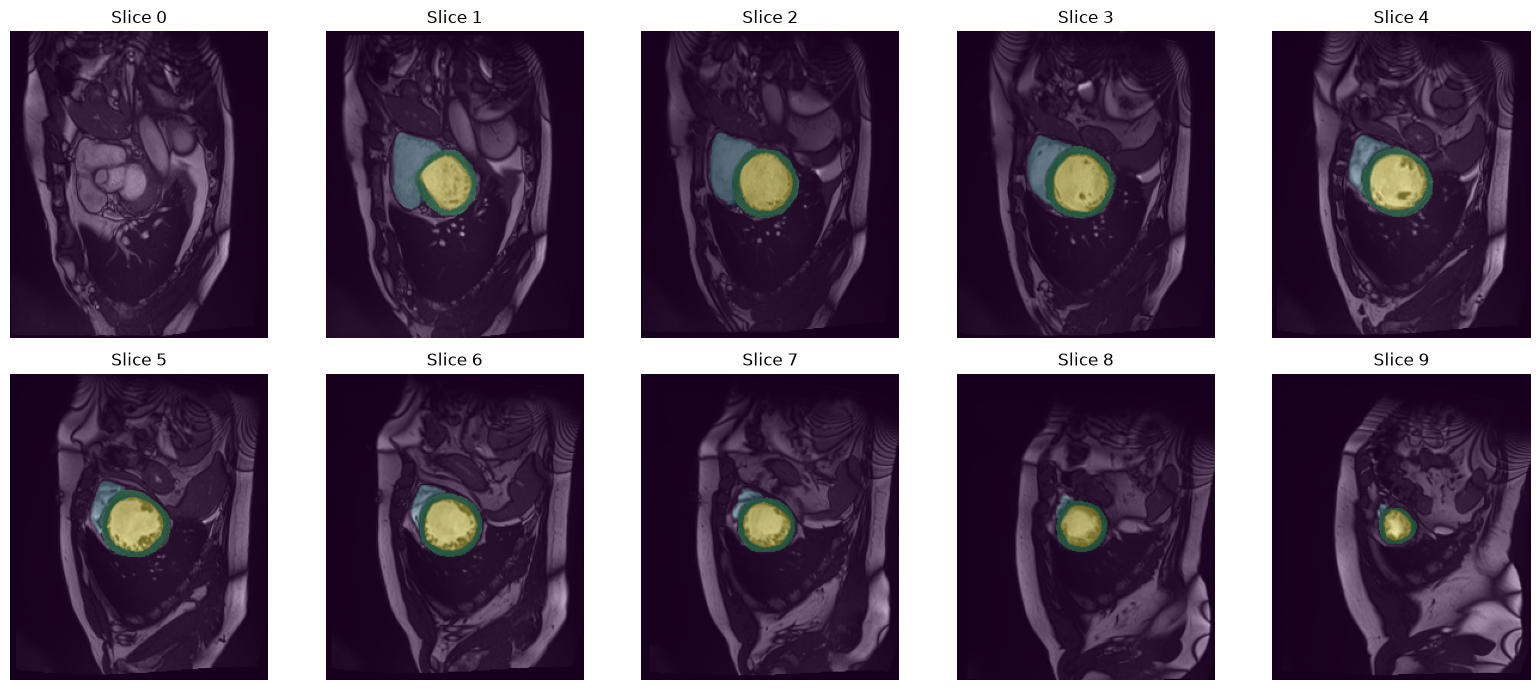

In [28]:
num_slices = ed.shape[2]

fig, axes = plt.subplots(
    2,
    int(np.ceil(num_slices / 2)),
    figsize=(16, 7)
)

axes = axes.flatten()

for z in range(num_slices):

    axes[z].imshow(
        ed[:, :, z].T,
        cmap="gray",
        origin="lower"
    )

    axes[z].imshow(
        gt[:, :, z].T,
        cmap="viridis",
        origin="lower",
        alpha=0.35
    )

    axes[z].set_title(f"Slice {z}")
    axes[z].axis("off")

for ax in axes[num_slices:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
es_frame = int(info["ES"])

es_path = patient_dir / f"{patient_name}_frame{es_frame:02d}.nii.gz"
es_gt_path = patient_dir / f"{patient_name}_frame{es_frame:02d}_gt.nii.gz"

es_img = nib.load(es_path)
es = es_img.get_fdata()

es_gt_img = nib.load(es_gt_path)
es_gt = es_gt_img.get_fdata()

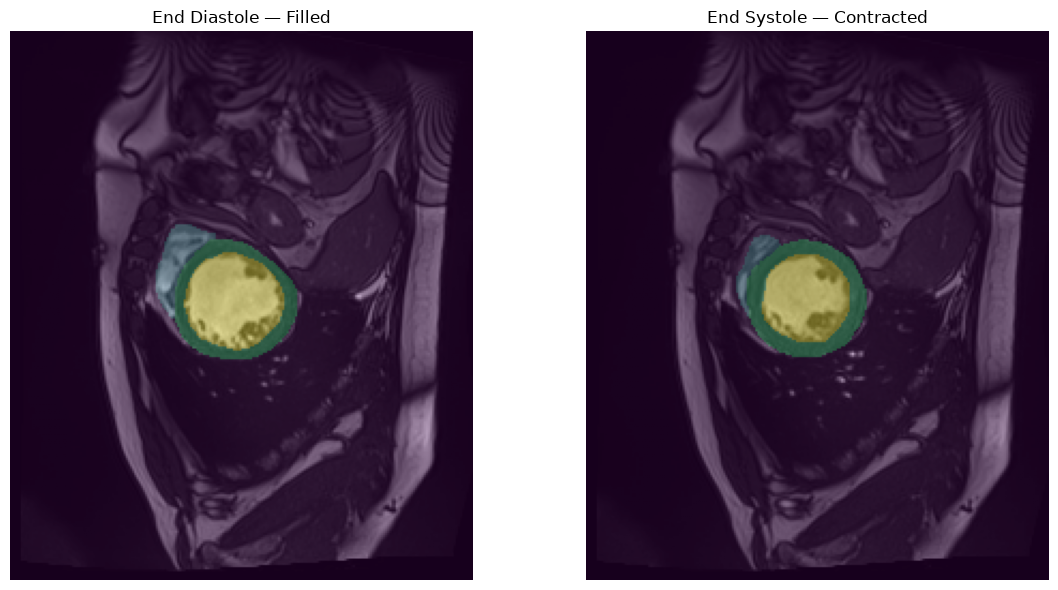

In [30]:
z = min(ed.shape[2], es.shape[2]) // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(ed[:, :, z].T, cmap="gray", origin="lower")
axes[0].imshow(gt[:, :, z].T, cmap="viridis", origin="lower", alpha=0.35)
axes[0].set_title("End Diastole — Filled")
axes[0].axis("off")

axes[1].imshow(es[:, :, z].T, cmap="gray", origin="lower")
axes[1].imshow(es_gt[:, :, z].T, cmap="viridis", origin="lower", alpha=0.35)
axes[1].set_title("End Systole — Contracted")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [31]:
cine_path = patient_dir / f"{patient_name}_4d.nii.gz"

cine_img = nib.load(cine_path)
cine = cine_img.get_fdata()

print(cine.shape)

(216, 256, 10, 30)
